In [1]:
# import pandas as pd
import xarray as xr 
# 
from dask.distributed import Client, LocalCluster


In [2]:
client = Client(LocalCluster())

/home1/nalex2023/.local/lib/python3.10/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 46879 instead
  warnings.warn(


In [3]:
inter_manus = '/home2/nalex2023/Datasets/interpsonde_manus/2012_MANUS_INTERPSONDEv2.nc'
inter_manus2 = '/home2/nalex2023/Datasets/interpsonde_manus/2011_MANUS_INTERPSONDEv2.nc'

dset_all = xr.open_mfdataset([inter_manus2,inter_manus])

dset_all['pres'] = dset_all['bar_pres'] * 10

dset_all = dset_all.roll(time=10, roll_coords=False)

dset_all = dset_all.compute()

/home1/nalex2023/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [4]:
dset_all

<xarray.Dataset> Size: 162MB
Dimensions:   (time: 17424, height: 332)
Coordinates:
  * height    (height) float32 1kB 0.004 0.024 0.044 0.064 ... 39.5 40.0 40.5
  * time      (time) datetime64[ns] 139kB 2011-01-01 ... 2012-12-31T23:00:00
Data variables:
    bar_pres  (time, height) float32 23MB nan nan nan nan ... nan nan nan nan
    temp      (time, height) float32 23MB 27.3 28.1 28.15 27.85 ... nan nan nan
    dp        (time, height) float32 23MB 23.52 23.53 23.49 ... nan nan nan
    rh        (time, height) float32 23MB 79.87 76.51 76.0 77.31 ... nan nan nan
    u_wind    (time, height) float32 23MB -1.047 -1.11 -1.494 ... nan nan nan
    v_wind    (time, height) float32 23MB 0.7149 0.4045 0.4858 ... nan nan nan
    pres      (time, height) float32 23MB nan nan nan nan ... nan nan nan nan
Attributes: (12/13)
    command_line:          idl -D 0 -R -n interpolatedsonde -s twp -f C1 -b 2...
    Conventions:           ARM-1.1
    process_version:       vap-interpolatedsonde-6.6-0.el6
    input_datastreams:     twpgriddedsondeC1.c0 : 2.2 : 20101230.000030-20110...
    dod_version:           interpolatedsonde-c1-4.0
    site_id:               twp
    ...                    ...
    facility_id:           C1
    data_level:            c1
    location_description:  Tropical Western Pacific (TWP), Manus Island, Papu...
    datastream:            twpinterpolatedsondeC1.c1
    doi:                   10.5439/1095316
    history:               created by user ttoto on machine chalk at 2016-05-...

In [5]:
dset_all['temp'] = dset_all['temp'].resample(time='1H').mean()
dset_all['dp'] = dset_all['dp'].resample(time='1H').mean()
dset_all['u_wind'] = dset_all['u_wind'].resample(time='1H').mean()
dset_all['v_wind'] = dset_all['v_wind'].resample(time='1H').mean()
dset_all['pres'] = dset_all['pres'].resample(time='1H').mean()

/home1/nalex2023/.local/lib/python3.10/site-packages/xarray/groupers.py:498: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  self.index_grouper = pd.Grouper(
/home1/nalex2023/.local/lib/python3.10/site-packages/xarray/groupers.py:498: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  self.index_grouper = pd.Grouper(
/home1/nalex2023/.local/lib/python3.10/site-packages/xarray/groupers.py:498: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  self.index_grouper = pd.Grouper(
/home1/nalex2023/.local/lib/python3.10/site-packages/xarray/groupers.py:498: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  self.index_grouper = pd.Grouper(
/home1/nalex2023/.local/lib/python3.10/site-packages/xarray/groupers.py:498: FutureWarning: 'H' is deprecated and will be removed in a future version, please us

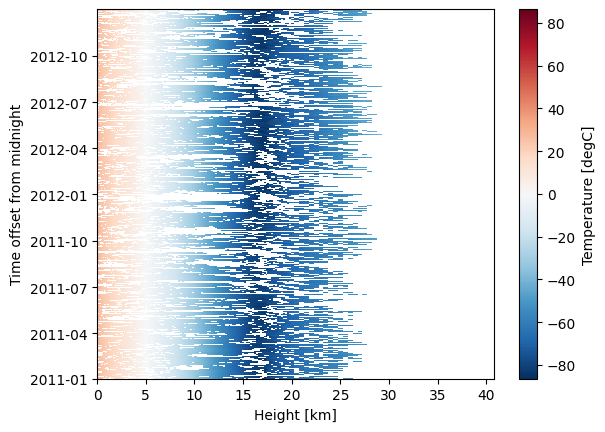

In [6]:
dset_all['temp'].plot()

In [7]:
from metpy.units import units
from metpy.calc import specific_humidity_from_dewpoint as sp_dp

def create_all_components(final_composite):
    
    
    #new_temp = filter_temp(final_composite['temp'])
    
    new_composite = ((final_composite['temp']+ 273.15) * units('kelvin')).to_dataset()
    
    
    cp = 1.00464 * units('kJ/kg/K')
    new_composite['tempcp'] = (new_composite['temp'] * cp).metpy.convert_units('m^2/s^2')
    new_composite['tempcp'].attrs = {'long_name':'CpT','units':'m^2 s^-2'}
    
    hpa_pres = final_composite['pres'] * units('hPa')
    #
    #
    #new_composite['spec_hum'].attrs = {'long_name':'q','units':'g/g'}
    try:
        new_composite['spec_hum'] = final_composite['sh'] * units('g/g')
    except KeyError:

        dp_c = final_composite['dp'] * units('degC')
        new_composite['spec_hum'] = sp_dp(pressure=hpa_pres,
                                          dewpoint=dp_c).metpy.convert_units('g/g')
        
    #sh_data = final_composite['sh'] * units('g/g')
    
    
    lv = (2.373 * 10**6) * units('J/kg')
    new_composite['spec_humlv'] = (new_composite['spec_hum'] * lv).metpy.convert_units('meters **2 / seconds **2')
    new_composite['spec_humlv'].attrs = {'long_name':'lvq','units':'m^2 s^-2'}
    

    g = 9.8 * units('m/s^2')    
    new_composite['gz'] = ((final_composite['height'] *1000* units('m'))  * g).metpy.convert_units('meters **2 / seconds **2')
    
    
    new_composite['mse'] = (new_composite['tempcp'] + 
                            new_composite['spec_humlv'] +
                            new_composite['gz'])
    
    
    new_composite['mse'].attrs = {'long_name':'mse','units':'m^2 s^-2'}
    
    new_composite['u_wind'] = final_composite['u_wind']
    new_composite['v_wind'] = final_composite['v_wind']
    new_composite['temp'] = final_composite['temp']
     

    return new_composite

final_dset = create_all_components(dset_all)

In [8]:
final_dset_sub = final_dset.sel(time=slice('2011-01-01','2012-06-01')).sel(height=slice(0,10))

In [9]:
final_dset_mean = final_dset_sub.groupby('time.hour').mean(dim='time')

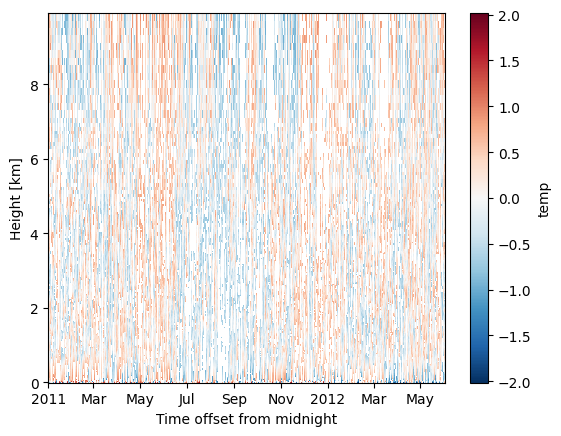

In [10]:
total_anom = final_dset_sub - final_dset_sub.mean(dim='time')

total_anom['temp'].plot(x='time')

In [11]:
final_dset_sub['spec_humlv'].sel(time=~final_dset_sub['time'].dt.strftime('%Y-%m-%d').isin(breeze_days)).groupby('time.hour').mean(dim='time').mean(dim='hour').plot(y='height')#(label='Seabreeze Days',x='hour')

NameError: name 'breeze_days' is not defined

In [12]:
import pandas as pd

In [13]:
sea_breeze_days = pd.read_csv('/home1/nalex2023/Datasets/LSB_OUTS/sea_breeze.csv')

breeze_days = pd.to_datetime(sea_breeze_days['datetime']).apply(lambda x: str(x.date()))

# select days from final_dset that are in breeze_days

#final_dset_seabreeze = final_dset_sub_anomaly.sel(time=final_dset_sub_anomaly['time'].dt.strftime('%Y-%m-%d').isin(breeze_days))

#final_dset_non_seabreeze = final_dset_sub_anomaly.sel(time=~final_dset_sub_anomaly['time'].dt.strftime('%Y-%m-%d').isin(breeze_days))

seabreeze_anomaly = final_dset_sub.sel(time=final_dset_sub['time'].dt.strftime('%Y-%m-%d').isin(breeze_days)).groupby('time.hour').mean() - final_dset_mean

non_seabreeze_anom = final_dset_sub.sel(time=~final_dset_sub['time'].dt.strftime('%Y-%m-%d').isin(breeze_days)).groupby('time.hour').mean() - final_dset_mean





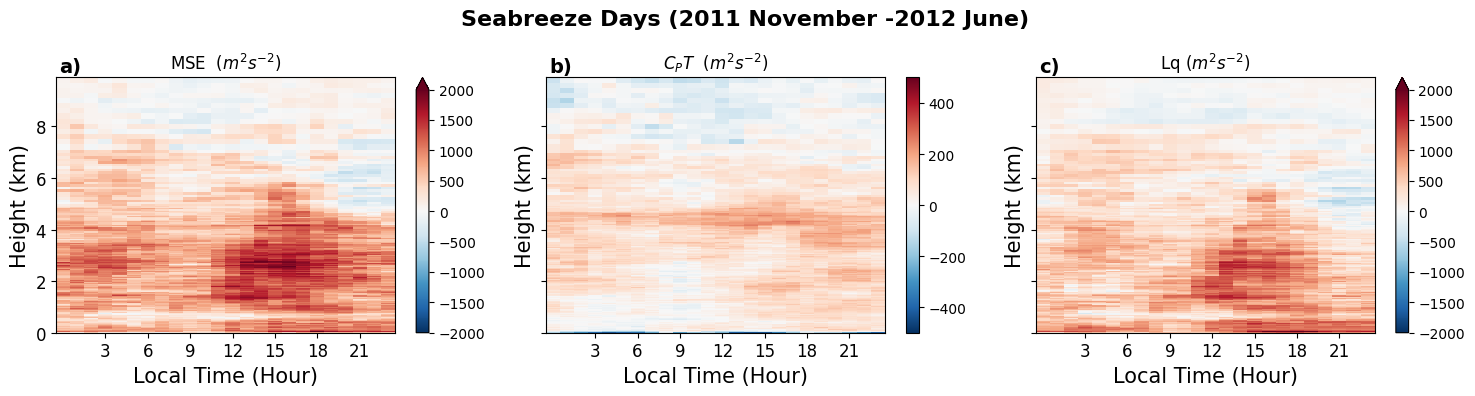

In [16]:
import matplotlib.pyplot as plt
fig,ax = plt.subplots(1,3,figsize=(15,4),sharey=True)
seabreeze_anomaly['mse'].plot(x='hour',ax=ax[0],cbar_kwargs={'label': ''},vmin=-2000,vmax=2000,cmap='RdBu_r')
seabreeze_anomaly['tempcp'].plot(x='hour',ax=ax[1],cbar_kwargs={'label': ''},vmin=-500,vmax=500,cmap='RdBu_r')
seabreeze_anomaly['spec_humlv'].plot(x='hour',ax=ax[2],cbar_kwargs={'label': ''},vmin=-2000,vmax=2000,cmap='RdBu_r')


ax[0].set_title('MSE  ($m^2 s^{-2}$)',)
ax[1].set_title('$C_{P}T$  ($m^2 s^{-2}$)')
ax[2].set_title('Lq ($m^2 s^{-2}$)')

# a , b , c 
ax[0].text(0.01, 1.02, 'a)', transform=ax[0].transAxes, fontsize=14, fontweight='bold')
ax[1].text(0.01, 1.02, 'b)', transform=ax[1].transAxes, fontsize=14, fontweight='bold')
ax[2].text(0.01, 1.02, 'c)', transform=ax[2].transAxes, fontsize=14, fontweight='bold')

for ii in ax:
    # x ticks every 2 hours
    ii.set_xticks(range(3,24,3))
    ii.tick_params(axis='both', which='both', labelsize=12)
    ii.set_ylabel('Height (km)',fontsize=15)
    ii.set_xlabel('Local Time (Hour)',fontsize=15)

fig.suptitle('Seabreeze Days (2011 November -2012 June)',weight='bold',fontsize=16)
plt.tight_layout()


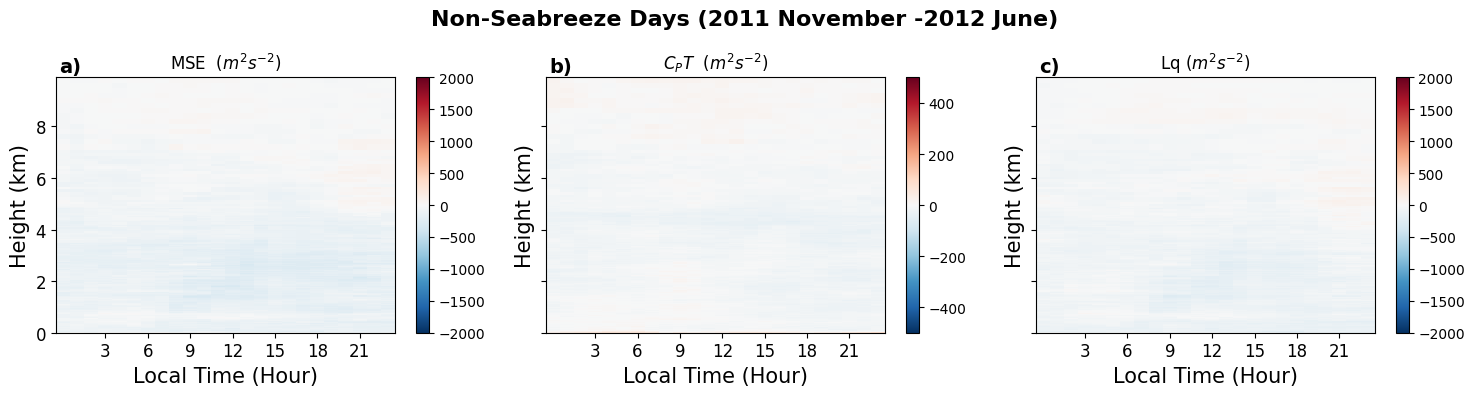

In [17]:
#fig,ax = plt.subplots(1,3,figsize=(15,3))
#non_seabreeze_anom['mse'].plot(x='hour',ax=ax[0])
#non_seabreeze_anom['tempcp'].plot(x='hour',ax=ax[1])
#non_seabreeze_anom['spec_humlv'].plot(x='hour',ax=ax[2])

fig,ax = plt.subplots(1,3,figsize=(15,4),sharey=True)

non_seabreeze_anom['mse'].plot(x='hour',ax=ax[0],cbar_kwargs={'label': ''},vmin=-2000,vmax=2000,cmap='RdBu_r')
non_seabreeze_anom['tempcp'].plot(x='hour',ax=ax[1],cbar_kwargs={'label': ''},vmin=-500,vmax=500,cmap='RdBu_r')
non_seabreeze_anom['spec_humlv'].plot(x='hour',ax=ax[2],cbar_kwargs={'label': ''},vmin=-2000,vmax=2000,cmap='RdBu_r')  


ax[0].set_title('MSE  ($m^2 s^{-2}$)')
ax[1].set_title('$C_{P}T$  ($m^2 s^{-2}$)')
ax[2].set_title('Lq ($m^2 s^{-2}$)')

ax[0].text(0.01, 1.02, 'a)', transform=ax[0].transAxes, fontsize=14, fontweight='bold')
ax[1].text(0.01, 1.02, 'b)', transform=ax[1].transAxes, fontsize=14, fontweight='bold')
ax[2].text(0.01, 1.02, 'c)', transform=ax[2].transAxes, fontsize=14, fontweight='bold')

for ii in ax:
    # x ticks every 2 hours
    ii.set_xticks(range(3,24,3))
    ii.tick_params(axis='both', which='both', labelsize=12)
    ii.set_ylabel('Height (km)',fontsize=15)
    ii.set_xlabel('Local Time (Hour)',fontsize=15)


fig.suptitle('Non-Seabreeze Days (2011 November -2012 June)',weight='bold',fontsize=16)
plt.tight_layout()

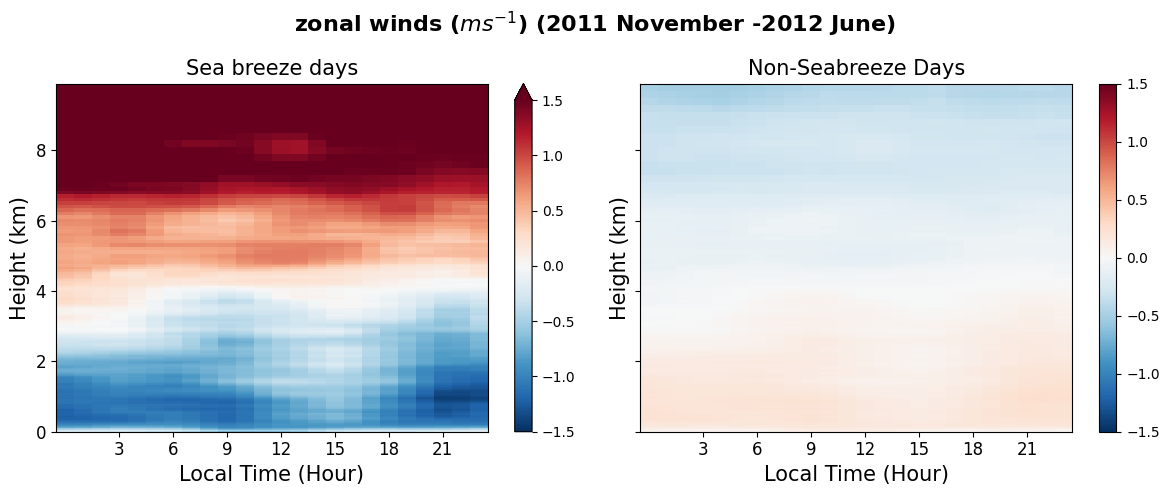

In [152]:
fig,ax = plt.subplots(1,2,figsize=(12,5),sharey=True)

seabreeze_anomaly['u_wind'].plot(x='hour',ax=ax[0],cbar_kwargs={'label': ''},vmin=-1.5,vmax=1.5,cmap='RdBu_r')
non_seabreeze_anom['u_wind'].plot(x='hour',ax=ax[1],cbar_kwargs={'label': ''},vmin=-1.5,vmax=1.5,cmap='RdBu_r')



ax[0].set_title('Sea breeze days',fontsize=15)
ax[1].set_title('Non-Seabreeze Days',fontsize=15)

for ii in ax:
    ii.set_xticks(range(3,24,3))
    ii.tick_params(axis='both', which='both', labelsize=12)
    ii.set_ylabel('Height (km)',fontsize=15)
    ii.set_xlabel('Local Time (Hour)',fontsize=15)

fig.suptitle('zonal winds ($m s^{-1}$) (2011 November -2012 June)',weight='bold',fontsize=16)
plt.tight_layout()

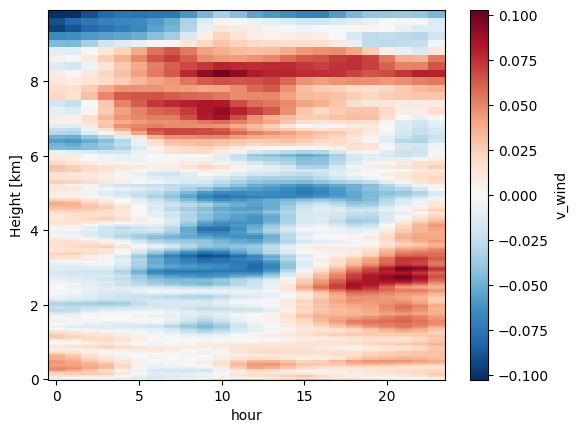

In [186]:
non_seabreeze_anom['v_wind'].plot(x='hour')

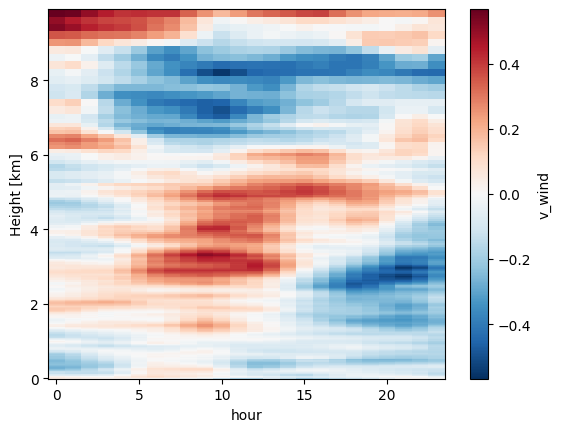

In [187]:
seabreeze_anomaly['v_wind'].plot(x='hour')

In [87]:
event_times = pd.read_csv('/home2/nalex2023/Datasets/1d_EXP_outs/2012_Feb_event_timeONLY_3636.csv')
sea_breeze_days = pd.read_csv('/home1/nalex2023/Datasets/LSB_OUTS/sea_breeze.csv')

In [109]:

event_times_dates = pd.to_datetime(event_times['time']).dt.date

test_times = event_times_dates.drop_duplicates()[:52]#.to_csv('/home1/nalex2023/Datasets/LSB_OUTS/3215.csv',index=False)

In [110]:
test_times = pd.to_datetime(test_times).to_frame(name='test_time')


In [113]:
test_times['hours'] = np.arange(-36,16)

In [115]:
-170/24

-7.083333333333333

In [114]:
test_times

,test_time,hours
0,2012-02-05,-36
24,2012-02-06,-35
48,2012-02-07,-34
72,2012-02-08,-33
96,2012-02-09,-32
120,2012-02-10,-31
144,2012-02-11,-30
168,2012-02-12,-29
192,2012-02-13,-28
216,2012-02-14,-27


In [134]:
len(test_times.set_index('hours').loc[3:])

13

In [100]:
sea_breeze_days_days = pd.to_datetime(sea_breeze_days['datetime'])

In [116]:
# merge test_times and sea_breeze_days_days to find common days

merged_days = pd.merge(test_times, sea_breeze_days_days.to_frame(name='sea_breeze_time'), left_on='test_time', right_on='sea_breeze_time', how='inner')

In [118]:
final_frame = merged_days.set_index('hours')

In [122]:
len(final_frame.loc[-36:-7])

13

In [123]:
73/24

3.0416666666666665

In [124]:
len(final_frame.loc[-7:3])

7

In [125]:
len(final_frame.loc[-3:])

7

In [127]:
13/27

0.48148148148148145

In [130]:
13/30

0.43333333333333335

In [133]:
7/11

0.6363636363636364

In [135]:
7/13

0.5384615384615384